# Week 2 Practice — HMAF: Fusing Hand-crafted and Deep Features

Welcome! In the Week 2 session you learned about **HMAF (Hybrid Modality Attention-based Fusion)** —
our method for combining two kinds of features extracted from cell nuclei in histopathology images:

1. **Hand-crafted features** (24 columns) — simple, interpretable measurements a human designed:
   cell size, shape, color, and intensity (e.g. `area`, `perimeter`, `r_mean`).
2. **Deep-learned features** (128 columns) — numbers produced by a neural network (ResNet-50)
   that looked at a small image patch of each nucleus. They are powerful but hard to interpret.
   (They were compressed with PCA, so the columns are named `pca_0` ... `pca_127`.)

In this notebook you will build a **binary (positive vs. negative) nucleus classifier** —
exactly the setting used in our HIMLT tool — and compare four approaches:

| # | Approach | Features used |
|---|----------|---------------|
| A | Hand-crafted only | 24 |
| B | Deep only | 128 |
| C | Simple concatenation | 24 + 128 = 152 |
| D | **HMAF fusion** | attention-fused + originals |

**Task:** *Epithelial vs. Others* — is a nucleus an epithelial cell (positive) or not (negative)?

**How to use this notebook:** run the cells from top to bottom, one at a time
(click a cell and press `Shift+Enter`). Read the text between cells — it explains what each step does.

**Setup:** just run the cells — the first code cell downloads the feature file
(`consep_features_24hand_128deep.csv`, ~61 MB) automatically from Google Drive.
If you already have the CSV next to the notebook, the download is skipped.


## Step 0a — Get the data

The cell below fetches the feature CSV from Google Drive (it skips the download if the
file is already there, e.g. if you placed it next to the notebook yourself).

In [1]:
import os

CSV_NAME = "consep_features_24hand_128deep.csv"
DRIVE_FILE_ID = "1_UttTq217yQrwliRKfUbvNGAfA0HkuRR"

if os.path.exists(CSV_NAME):
    print(f"{CSV_NAME} already present — skipping download.")
else:
    import gdown  # pre-installed on Google Colab
    gdown.download(id=DRIVE_FILE_ID, output=CSV_NAME, quiet=False)
    print("Download complete!")

consep_features_24hand_128deep.csv already present — skipping download.


## Step 0b — Imports

We use standard Python data-science libraries:
- `pandas` / `numpy` — tables and math
- `matplotlib` — plots
- `scikit-learn` — metrics and preprocessing
- `xgboost` — the classifier that performed best in our paper
- `torch` (PyTorch) — to build the HMAF attention module

All of these are pre-installed on Google Colab.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from xgboost import XGBClassifier

# Fix random seeds so everyone gets the same numbers
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1 — Load the data

Each **row** of the CSV is one cell nucleus from the CoNSeP dataset
(41 colorectal cancer tissue images, ~21,000 annotated nuclei).
Each **column** is either metadata (which image it came from, its position),
a hand-crafted feature, a deep feature, or the label `cell_type`.

In [3]:
df = pd.read_csv("consep_features_24hand_128deep.csv")

print(f"The table has {df.shape[0]:,} nuclei (rows) and {df.shape[1]} columns.")
df.head()

The table has 21,478 nuclei (rows) and 162 columns.


,image_name,dataset_split,instance_id,centroid_x,centroid_y,cell_type,bbox_x0,bbox_y0,bbox_x1,bbox_y1,...,pca_118,pca_119,pca_120,pca_121,pca_122,pca_123,pca_124,pca_125,pca_126,pca_127
0,train_1,train,1,222.541053,112.966842,4,197,85,252,145,...,0.133934,0.466055,0.023358,0.163106,0.175861,-0.066862,0.143868,-0.014156,-0.087940,-0.198783
1,train_1,train,2,235.037484,769.942821,4,209,743,263,797,...,0.519758,0.316371,-0.299449,0.136557,0.334146,0.354581,0.292068,0.140261,0.204194,-0.027573
2,train_1,train,3,184.677636,684.558093,4,162,656,210,712,...,-0.280005,0.243753,-0.170138,0.262977,0.390239,-0.040814,0.039194,-0.315035,0.179316,-0.092039
3,train_1,train,4,18.276307,657.013578,4,0,627,41,690,...,0.187025,0.010759,0.073304,0.287923,0.216945,-0.075185,0.323552,-0.504223,0.303811,0.217560
4,train_1,train,5,193.129374,198.864117,4,171,163,220,231,...,0.003600,0.160850,-0.077092,-0.103800,-0.438104,0.290731,0.233463,0.162017,-0.131194,0.159331


### What cell types are in the data?

CoNSeP labels every nucleus with one of 7 cell types. Let's count them.

Other                      846
Inflammatory              5043
Epithelial (healthy)      1620
Epithelial (malignant)    6153
Fibroblast                6707
Muscle                    1058
Endothelial                 51
Name: count, dtype: int64


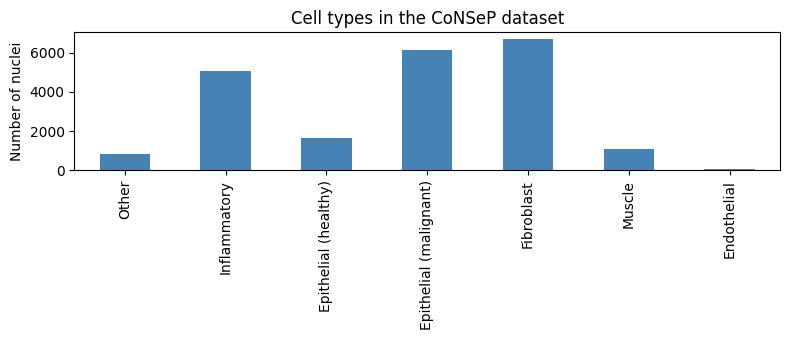

In [4]:
CELL_TYPE_NAMES = {
    1: "Other",
    2: "Inflammatory",
    3: "Epithelial (healthy)",
    4: "Epithelial (malignant)",
    5: "Fibroblast",
    6: "Muscle",
    7: "Endothelial",
}

counts = df["cell_type"].value_counts().sort_index()
counts.index = [CELL_TYPE_NAMES[i] for i in counts.index]
print(counts)

counts.plot(kind="bar", color="steelblue", figsize=(8, 3.5))
plt.ylabel("Number of nuclei")
plt.title("Cell types in the CoNSeP dataset")
plt.tight_layout()
plt.show()

## Step 2 — Create the positive vs. negative label

Just like in HIMLT, we turn this into a **binary** question.
Following our paper, types 3 and 4 together form the **Epithelial** group:

- **Positive (1):** epithelial nuclei (types 3 and 4)
- **Negative (0):** everything else (inflammatory, fibroblast, muscle, ...)

In [5]:
df["label"] = df["cell_type"].isin([3, 4]).astype(int)

print(df["label"].value_counts().rename({1: "Positive (Epithelial)", 0: "Negative (Others)"}))
print(f"\n{df['label'].mean():.1%} of the nuclei are positive.")

label
Negative (Others)        13705
Positive (Epithelial)     7773
Name: count, dtype: int64

36.2% of the nuclei are positive.


## Step 3 — Split into modalities, and into train / test

Two things happen here:

1. We separate the columns into the **hand-crafted matrix `H`** (24 columns) and the
   **deep matrix `D`** (128 columns). Metadata columns (image name, position, ...) are dropped —
   the classifier should only see image-derived measurements.
2. We split into **train** and **test** sets using the `dataset_split` column.
   This split is **by image** (27 training images, 14 test images), the same split used in the paper.

> **Why not split randomly?** Nuclei from the same image look alike (same staining, same patient).
> If nuclei from one image ended up in both train and test, the model could "cheat" by
> memorizing the image style instead of learning real biology. This mistake is called
> **data leakage** — splitting by image prevents it.

We also **standardize** each feature (subtract mean, divide by standard deviation).
Important detail: the mean/std are computed **on the training set only**, then applied to the
test set — computing them on all data would be another subtle form of leakage.

In [6]:
HAND_COLS = ['rb_ratio', 'r_median', 'r_mean', 'b_dominance', 'r_dominance',
             'intensity_median', 'intensity_mean', 'b_median', 'b_mean', 'r_min',
             'g_median', 'g_mean', 'gb_ratio', 'intensity_min', 'g_min',
             'perimeter', 'equivalent_diameter', 'feret_diameter_max', 'g_dominance',
             'major_axis_length', 'area', 'b_min', 'minor_axis_length', 'elongation']
DEEP_COLS = [f"pca_{i}" for i in range(128)]

# A few cells have missing values; fill them with the training-set median
train_mask = df["dataset_split"] == "train"
medians = df.loc[train_mask, HAND_COLS + DEEP_COLS].median()
df[HAND_COLS + DEEP_COLS] = df[HAND_COLS + DEEP_COLS].fillna(medians)

train_df = df[train_mask]
test_df  = df[~train_mask]

y_train = train_df["label"].values
y_test  = test_df["label"].values

# Standardize each modality (fit on train only!)
hand_scaler = StandardScaler().fit(train_df[HAND_COLS])
deep_scaler = StandardScaler().fit(train_df[DEEP_COLS])

H_train = hand_scaler.transform(train_df[HAND_COLS])
H_test  = hand_scaler.transform(test_df[HAND_COLS])
D_train = deep_scaler.transform(train_df[DEEP_COLS])
D_test  = deep_scaler.transform(test_df[DEEP_COLS])

print(f"Train: {H_train.shape[0]:,} nuclei   |  Test: {H_test.shape[0]:,} nuclei")
print(f"Hand-crafted matrix H: {H_train.shape[1]} features")
print(f"Deep matrix D:         {D_train.shape[1]} features")

Train: 15,555 nuclei   |  Test: 5,923 nuclei
Hand-crafted matrix H: 24 features
Deep matrix D:         128 features


## Step 4 — Baselines: how good is each modality on its own?

Before fusing anything, we need reference points. We train the same classifier
(**XGBoost**, the best model in our paper) three times:

- **A.** on hand-crafted features only
- **B.** on deep features only
- **C.** on both, simply glued side by side (concatenation)

The helper function below trains a model and reports five standard metrics.
`scale_pos_weight` tells XGBoost that the classes are imbalanced
(there are fewer positives than negatives).

In [7]:
def train_and_evaluate(X_train, X_test, name):
    """Train an XGBoost classifier and return a dict of test-set metrics."""
    # Ratio of negatives to positives, so the model pays fair attention to the smaller class
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    model = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=pos_weight,
        eval_metric="logloss", random_state=42, n_jobs=-1,
    )
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Approach":  name,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall":    recall_score(y_test, pred),
        "F1":        f1_score(y_test, pred),
        "ROC-AUC":   roc_auc_score(y_test, prob),
    }
    print(f"{name:28s}  Accuracy={metrics['Accuracy']:.4f}  F1={metrics['F1']:.4f}  ROC-AUC={metrics['ROC-AUC']:.4f}")
    return metrics

results = []

In [8]:
# Baseline A — hand-crafted features only (24 features)
results.append(train_and_evaluate(H_train, H_test, "A. Hand-crafted only"))

A. Hand-crafted only          Accuracy=0.8023  F1=0.7297  ROC-AUC=0.8798


In [9]:
# Baseline B — deep features only (128 features)
results.append(train_and_evaluate(D_train, D_test, "B. Deep only"))

B. Deep only                  Accuracy=0.8523  F1=0.7982  ROC-AUC=0.9166


In [10]:
# Baseline C — simple concatenation (24 + 128 = 152 features side by side)
C_train = np.hstack([H_train, D_train])
C_test  = np.hstack([H_test,  D_test])
results.append(train_and_evaluate(C_train, C_test, "C. Concatenation"))

C. Concatenation              Accuracy=0.8531  F1=0.7982  ROC-AUC=0.9208


## Step 5 — HMAF: Hybrid Modality Attention-based Fusion

Concatenation treats every feature equally. HMAF instead **weights the two modalities
per nucleus**: for one cell the shape measurements might matter more, for another the deep
features might. Here is the recipe (equation numbers match the paper):

1. **Project both modalities to a common size** *p* (Eq. 1–2):
   `H_proj = W_H · H + b_H` and `D_proj = W_D · D + b_D` — two linear layers.
2. **Score each modality** with its own tiny MLP (Eq. 3–4):
   `α = sigmoid(MLP_H(H_proj))`, `β = sigmoid(MLP_D(D_proj))` — one number per nucleus per modality.
3. **Normalize** the two scores with softmax so they compete: `[w_H, w_D] = softmax([α, β])` (Eq. 5).
   Now `w_H + w_D = 1` for every nucleus.
4. **Fuse** with a weighted sum (Eq. 6): `F = w_H · H_proj + w_D · D_proj`.
5. **Keep the originals too** (Eq. 7): the final feature vector is `[F, H, D]` —
   the fused representation plus both raw modalities.

The class below is the exact module from our published code — read it line by line
and match each part to the five steps above.

In [11]:
class ModalityAttentionFusion(nn.Module):
    """HMAF fusion block (Eq. 1-7 of the paper)."""

    def __init__(self, hand_dim=24, deep_dim=128, proj_dim=128, hidden_dim=64):
        super().__init__()
        # Step 1: projection layers to a common dimension (Eq. 1-2)
        self.hand_proj = nn.Linear(hand_dim, proj_dim)
        self.deep_proj = nn.Linear(deep_dim, proj_dim)
        # Step 2: modality-specific attention MLPs (Eq. 3-4)
        self.hand_mlp = nn.Sequential(
            nn.Linear(proj_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        self.deep_mlp = nn.Sequential(
            nn.Linear(proj_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))

    def forward(self, hand_features, deep_features):
        # Step 1: project (Eq. 1-2)
        hand_proj = self.hand_proj(hand_features)   # (batch, proj_dim)
        deep_proj = self.deep_proj(deep_features)   # (batch, proj_dim)

        # Step 2: one attention score per modality (Eq. 3-4)
        alpha = torch.sigmoid(self.hand_mlp(hand_proj))   # weight for hand-crafted
        beta  = torch.sigmoid(self.deep_mlp(deep_proj))   # weight for deep

        # Step 3: softmax so the two weights sum to 1 (Eq. 5)
        weights = F.softmax(torch.cat([alpha, beta], dim=1), dim=1)
        w_hand, w_deep = weights[:, 0:1], weights[:, 1:2]

        # Step 4: weighted fusion (Eq. 6)
        fused = w_hand * hand_proj + w_deep * deep_proj

        # Step 5: concatenate fused + original features (Eq. 7)
        final_features = torch.cat([fused, hand_features, deep_features], dim=1)
        return final_features, w_hand, w_deep


fusion_model = ModalityAttentionFusion(hand_dim=len(HAND_COLS), deep_dim=len(DEEP_COLS))
fusion_model.eval()   # we only run the module forward, exactly as in the published pipeline

with torch.no_grad():
    F_train, w_hand_train, _ = fusion_model(torch.tensor(H_train, dtype=torch.float32),
                                            torch.tensor(D_train, dtype=torch.float32))
    F_test,  w_hand_test,  _ = fusion_model(torch.tensor(H_test,  dtype=torch.float32),
                                            torch.tensor(D_test,  dtype=torch.float32))

F_train = F_train.numpy()
F_test  = F_test.numpy()

print(f"HMAF output: {F_train.shape[1]} features per nucleus "
      f"(128 fused + {len(HAND_COLS)} hand-crafted + {len(DEEP_COLS)} deep)")

HMAF output: 280 features per nucleus (128 fused + 24 hand-crafted + 128 deep)


In [12]:
# Approach D — classify with the HMAF-fused features
results.append(train_and_evaluate(F_train, F_test, "D. HMAF fusion (ours)"))

D. HMAF fusion (ours)         Accuracy=0.8550  F1=0.8009  ROC-AUC=0.9239


## Step 6 — Compare all four approaches

Let's put everything side by side and save the table and chart to the `results/` folder.

,Accuracy,Precision,Recall,F1,ROC-AUC
Approach,,,,,
A. Hand-crafted only,0.8023,0.7539,0.7071,0.7297,0.8798
B. Deep only,0.8523,0.8242,0.7737,0.7982,0.9166
C. Concatenation,0.8531,0.8290,0.7697,0.7982,0.9208
D. HMAF fusion (ours),0.8550,0.8312,0.7728,0.8009,0.9239


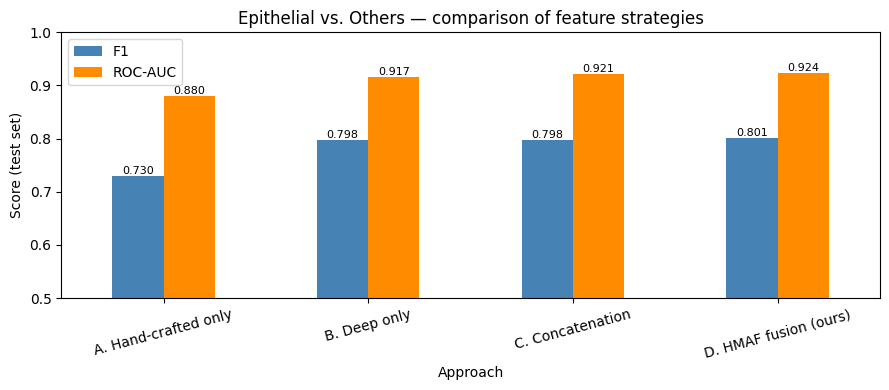

Saved: results/comparison_epithelial_vs_others.csv and .png


In [13]:
results_df = pd.DataFrame(results).set_index("Approach")
display(results_df.round(4))

# Bar chart comparing F1 and ROC-AUC
ax = results_df[["F1", "ROC-AUC"]].plot(kind="bar", figsize=(9, 4),
                                        color=["steelblue", "darkorange"], rot=15)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Score (test set)")
ax.set_title("Epithelial vs. Others — comparison of feature strategies")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)
plt.tight_layout()

import os
os.makedirs("results", exist_ok=True)
plt.savefig("results/comparison_epithelial_vs_others.png", dpi=150)
results_df.round(4).to_csv("results/comparison_epithelial_vs_others.csv")
plt.show()
print("Saved: results/comparison_epithelial_vs_others.csv and .png")

## Step 7 — Look inside HMAF: the attention weights

One advantage of HMAF over plain concatenation is that we can **inspect** it:
for every nucleus we get `w_hand` (and `w_deep = 1 − w_hand`) — how much the fusion
leaned on each modality for that particular cell.

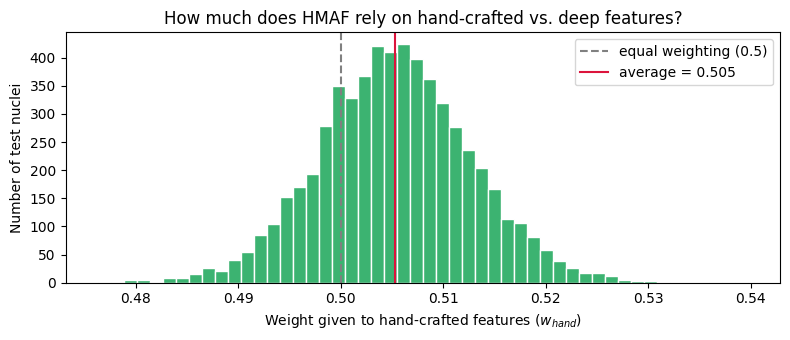

On average, HMAF gives 50.5% of the weight to hand-crafted features and 49.5% to deep features.


In [14]:
w = w_hand_test.numpy().ravel()

plt.figure(figsize=(8, 3.5))
plt.hist(w, bins=50, color="mediumseagreen", edgecolor="white")
plt.axvline(0.5, color="gray", linestyle="--", label="equal weighting (0.5)")
plt.axvline(w.mean(), color="crimson", linestyle="-",
            label=f"average = {w.mean():.3f}")
plt.xlabel("Weight given to hand-crafted features ($w_{hand}$)")
plt.ylabel("Number of test nuclei")
plt.title("How much does HMAF rely on hand-crafted vs. deep features?")
plt.legend()
plt.tight_layout()
plt.savefig("results/attention_weights_histogram.png", dpi=150)
plt.show()

print(f"On average, HMAF gives {w.mean():.1%} of the weight to hand-crafted features "
      f"and {1 - w.mean():.1%} to deep features.")

## Take-home exercises

Try these during the week — each one is a small edit to a single cell.
Bring your results (numbers or plots) to the next session!

1. **Change the positive class.** In Step 2, replace `isin([3, 4])` to make
   *Inflammatory vs. Others* (`isin([2])`) or *Spindle vs. Others* (`isin([5, 6, 7])`).
   Which task is easiest? Does HMAF help more, or less?
2. **Try a different classifier.** In `train_and_evaluate`, swap `XGBClassifier` for
   `RandomForestClassifier(n_estimators=300, random_state=42)` or
   `LogisticRegression(max_iter=2000)` (both from scikit-learn — remember to import them,
   and note that these models don't use `scale_pos_weight`; use `class_weight="balanced"` instead).
   Does XGBoost stay in front, as it did in the paper?
3. **Change the projection size.** In Step 5, try `proj_dim=64` or `proj_dim=256`.
   How does the final feature count and the score change?
4. **(Challenge) Train the attention.** In our published pipeline the fusion block is applied
   as a fixed transformation. Add a small classification head
   (`nn.Linear(final_dim, 1)`), train it end-to-end for a few epochs with
   `nn.BCEWithLogitsLoss()` and `torch.optim.Adam`, then re-extract the fused features.
   Do the learned attention weights move away from 0.5? Does the classifier improve?

### Recap

- Hand-crafted and deep features carry **complementary** information.
- Combining them helps, and **attention-based fusion (HMAF)** combines them adaptively,
  per nucleus, while staying interpretable via the attention weights.
- Careful methodology matters: split **by image**, standardize using **train statistics only**.
